# Bài tập 2: So sánh thuật toán Differential Evolution (DE) và Cross Entropy Method (CEM)

**Môn học:** Mạng Nơ-ron và Thuật toán Di truyền - CS410.Q2  
**Họ và tên:** Lê Nguyễn Quốc Bảo
**MSSV:** 23520108  

**Mục tiêu bài tập:**
Bài tập này tập trung vào việc cài đặt, thử nghiệm và đánh giá hiệu năng của hai thuật toán tối ưu hóa ngẫu nhiên: **Differential Evolution (DE)** và **Cross Entropy Method (CEM)**. Cụ thể, các thuật toán sẽ được đánh giá trên 5 hàm mục tiêu chuẩn (Benchmark functions) với các không gian số chiều ($d=2, 10$) và kích thước quần thể khác nhau. Bài tập cũng bao gồm việc kiểm định thống kê kết quả và trực quan hóa quá trình hội tụ thông qua đồ thị và ảnh động (GIF).

## 1. Khai báo Thư viện và Cấu hình Tiện ích

Phần này khởi tạo các thư viện cần thiết cho quá trình tính toán và trực quan hóa:
- `numpy`: Phục vụ các phép toán ma trận, mảng nhiều chiều và sinh số ngẫu nhiên.
- `pandas`: Lưu trữ, xử lý và tạo bảng báo cáo kết quả thí nghiệm.
- `matplotlib`: Dùng để vẽ đồ thị hội tụ và tạo các ảnh động (animation/GIF).
- `scipy.stats`: Cung cấp hàm `ttest_ind` để thực hiện kiểm định Welch's t-test nhằm so sánh ý nghĩa thống kê.
- `IPython.display`: Hỗ trợ hiển thị bảng biểu và hình ảnh định dạng HTML/Markdown trực tiếp trên Notebook.

Hàm `get_seed(i)` được định nghĩa để thiết lập seed ngẫu nhiên tĩnh dựa trên Mã số sinh viên (MSSV + i), đảm bảo tính tái lập (reproducibility) của các vòng lặp.

In [74]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy import stats
from IPython.display import display, Markdown, HTML

MSSV = 23520108

def get_seed(i):
    return MSSV + i

## 2. Định nghĩa các Hàm Đánh giá (Benchmark Functions)

Để đánh giá khả năng tối ưu hóa toàn cục của thuật toán, 5 hàm benchmark có đặc trưng khác nhau được sử dụng:
1. **Sphere Function**: Hàm liên tục, đơn giản, có dạng hình nón cong, chỉ có một cực tiểu toàn cục. Dùng để kiểm tra tốc độ hội tụ cơ bản.
2. **Rastrigin Function**: Chứa nhiều cực tiểu cục bộ được phân bố đều do có thành phần hàm Cosine. Đây là một hàm khó, dễ khiến thuật toán bị mắc kẹt.
3. **Rosenbrock Function**: Hay còn gọi là hàm thung lũng (valley/banana function). Cực tiểu toàn cục nằm trong một thung lũng dốc hẹp hình parabol, thử thách khả năng định hướng của thuật toán.
4. **Ackley Function**: Đặc trưng bởi một hố dốc sâu ở trung tâm và khu vực bề mặt gần như bằng phẳng phía ngoài chứa nhiều cực trị cục bộ nhỏ.
5. **Griewank Function**: Có sự liên kết giữa các biến (non-separable) và chứa nhiều cực trị cục bộ, tuy nhiên ở quy mô lớn nó có xu hướng giống hàm Sphere.

Dictionary `FUNCTIONS` được thiết lập để lưu trữ hàm tính toán kèm theo không gian tìm kiếm (bounds) và giá trị tối ưu toàn cục lý tưởng (`opt_val` = 0.0) của mỗi hàm.

In [75]:
def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    return 10 * len(x) + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

def rosenbrock(x):
    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2.0 + (1 - x[:-1])**2.0)

def ackley(x):
    d = len(x)
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(2 * np.pi * x))
    term1 = -20 * np.exp(-0.2 * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + 20 + np.e

def griewank(x):
    sum_sq = np.sum(x**2) / 4000.0
    prod_cos = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return sum_sq - prod_cos + 1.0

FUNCTIONS = {
    'Sphere': {'func': sphere, 'bound': [-5.12, 5.12], 'opt_val': 0.0},
    'Rastrigin': {'func': rastrigin, 'bound': [-5.12, 5.12], 'opt_val': 0.0},
    'Rosenbrock': {'func': rosenbrock, 'bound': [-5.0, 10.0], 'opt_val': 0.0},
    'Ackley': {'func': ackley, 'bound': [-32.0, 32.0], 'opt_val': 0.0},
    'Griewank': {'func': griewank, 'bound': [-600.0, 600.0], 'opt_val': 0.0},
}

## 3. Cài đặt thuật toán Differential Evolution (DE)

**Differential Evolution (DE)** là một thuật toán tiến hóa hoạt động trên các giá trị thực. Thuật toán được cài đặt với các bước cốt lõi sau:
1. **Khởi tạo (Initialization):** Quần thể gồm `popsize` cá thể được phân bố ngẫu nhiên đều (Uniform) trong giới hạn không gian biến.
2. **Đột biến (Mutation):** Sử dụng chiến lược `DE/rand/1`. Một vector đột biến được tạo ra bằng cách lấy một cá thể ngẫu nhiên cộng với hiệu của hai cá thể ngẫu nhiên khác được nhân với hệ số đột biến $F = 0.8$. Các giá trị vi phạm biên sẽ được cắt gọt (`np.clip`).
3. **Lai ghép (Crossover):** Thực hiện lai ghép nhị thức (Binomial Crossover) với xác suất lai ghép $CR = 0.9$. Đảm bảo có ít nhất một chiều không gian nhận giá trị từ vector đột biến để duy trì sự đa dạng.
4. **Chọn lọc (Selection):** So sánh giá trị fitness của cá thể thử nghiệm (trial) với cá thể gốc. Cá thể nào tốt hơn sẽ được giữ lại cho thế hệ tiếp theo.

Thuật toán hỗ trợ trả về lịch sử độ thích nghi (`history`) và vị trí quần thể (`pop_history`) nhằm phục vụ việc vẽ đồ thị và ảnh động.

In [76]:
def differential_evolution(func, bounds, popsize, max_evals, seed, return_history=False, return_pop_history=False):
    np.random.seed(seed)
    d = len(bounds)
    pop = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(popsize, d))
    fitness = np.apply_along_axis(func, 1, pop)
    evals = popsize
    best_idx = np.argmin(fitness)
    best_fit = fitness[best_idx]
    best_vector = pop[best_idx].copy()
    F = 0.8
    CR = 0.9
    history = [(evals, best_fit, best_vector.copy())]
    pop_history = [pop.copy()] if return_pop_history else []

    while evals < max_evals:
        for i in range(popsize):
            if evals >= max_evals:
                break
            idxs = [idx for idx in range(popsize) if idx != i]
            a, b, c = pop[np.random.choice(idxs, 3, replace=False)]
            mutant = np.clip(a + F * (b - c), bounds[:, 0], bounds[:, 1])
            cross_points = np.random.rand(d) < CR
            if not np.any(cross_points):
                cross_points[np.random.randint(0, d)] = True
            trial = np.where(cross_points, mutant, pop[i])
            f_trial = func(trial)
            evals += 1
            if f_trial < fitness[i]:
                pop[i] = trial
                fitness[i] = f_trial
                if f_trial < best_fit:
                    best_fit = f_trial
                    best_vector = trial.copy()
        if return_history:
            history.append((evals, best_fit, best_vector.copy()))
        if return_pop_history:
            pop_history.append(pop.copy())

    if return_history or return_pop_history:
        if return_history and return_pop_history:
            return best_fit, history, pop_history
        if return_history:
            return best_fit, history
        return best_fit, pop_history
    return best_fit

## 4. Cài đặt thuật toán Cross Entropy Method (CEM)

**Cross Entropy Method (CEM)** là thuật toán dựa trên nền tảng xác suất thống kê. Phương pháp này cập nhật một phân phối xác suất lặp đi lặp lại để thu hẹp dần vùng tìm kiếm tối ưu. Cài đặt bao gồm:
1. **Lấy mẫu (Sampling):** Lấy mẫu các cá thể từ phân phối chuẩn nhiều chiều (Multivariate Gaussian distribution) dựa vào vector kỳ vọng `mu` và ma trận hiệp phương sai `cov`.
2. **Đánh giá và Chọn lọc Elite:** Đánh giá độ thích nghi của mẫu và chỉ giữ lại một tỷ lệ các cá thể tốt nhất (`elite_ratio = 0.2` tương đương 20% cá thể xuất sắc).
3. **Đánh trọng số (Weighted update):** Các cá thể elite được gán trọng số theo thứ hạng (log-decay) sao cho cá thể có fitness tốt nhất sẽ đóng góp nhiều nhất vào việc định hình phân phối mới.
4. **Cập nhật tham số:** Cập nhật vector `mu` và ma trận `cov` mới. Kỹ thuật làm trơn (Exponential smoothing với hệ số `0.75`) và giá trị hiệp phương sai tối thiểu (`min_covar`) được sử dụng để duy trì đa dạng, tránh hiện tượng phân phối bị co cụm quá sớm (premature convergence).

In [77]:
def cross_entropy_method(
    func,
    bounds,
    popsize,
    max_evals,
    seed,
    elite_ratio=0.2,
    smoothing=0.75,
    min_covar=1e-6,
    return_history=False,
    return_pop_history=False,
):
    rng = np.random.default_rng(seed)
    d = len(bounds)
    n_elite = max(2, int(np.ceil(popsize * elite_ratio)))
    ranks = np.arange(1, n_elite + 1)
    raw_w = np.log(n_elite + 1) - np.log(ranks)
    elite_w = raw_w / np.sum(raw_w)
    lower, upper = bounds[:, 0], bounds[:, 1]
    mu = rng.uniform(lower, upper)
    span = upper - lower
    cov = np.diag((0.35 * span) ** 2)
    evals = 0
    best_fit = np.inf
    best_vector = None
    history = []
    pop_history = []

    while evals < max_evals:
        current_popsize = min(popsize, max_evals - evals)
        try:
            pop = rng.multivariate_normal(mu, cov, size=current_popsize)
        except np.linalg.LinAlgError:
            diag_std = np.sqrt(np.maximum(np.diag(cov), min_covar))
            pop = rng.normal(loc=mu, scale=diag_std, size=(current_popsize, d))
        pop = np.clip(pop, lower, upper)
        if return_pop_history:
            pop_history.append(pop.copy())
        fitness = np.apply_along_axis(func, 1, pop)
        evals += current_popsize
        current_min_fit = float(np.min(fitness))
        if current_min_fit < best_fit:
            best_fit = current_min_fit
            best_vector = pop[np.argmin(fitness)].copy()
        if return_history:
            history.append((evals, best_fit, best_vector.copy() if best_vector is not None else None))
        elite_idx = np.argsort(fitness)[: min(n_elite, current_popsize)]
        elites = pop[elite_idx]
        w = elite_w[: len(elites)]
        w = w / np.sum(w)
        mu_new = np.sum(elites * w[:, None], axis=0)
        centered = elites - mu_new
        cov_new = np.einsum("i,ij,ik->jk", w, centered, centered)
        cov_new += np.eye(d) * min_covar
        mu = smoothing * mu + (1 - smoothing) * mu_new
        cov = smoothing * cov + (1 - smoothing) * cov_new

    if return_history or return_pop_history:
        if return_history and return_pop_history:
            return best_fit, history, pop_history
        if return_history:
            return best_fit, history
        return best_fit, pop_history
    return best_fit

## 5. Thiết kế Thực nghiệm và Thu thập Dữ liệu

Phần này tiến hành chạy đánh giá và so sánh thực chứng hai thuật toán. Các cấu hình thử nghiệm được triển khai bám sát yêu cầu:
- **Số chiều không gian:** $d \in \{2, 10\}$.
- **Kích thước quần thể:** $N \in \{8, 16, 32, 64, 128\}$.
- **Số lần đánh giá hàm mục tiêu (Budget):** Dừng thuật toán khi gọi hàm đủ 2,000 lần (với $d=2$) hoặc 10,000 lần (với $d=10$).
- **Lặp lại thống kê:** Mỗi kịch bản được chạy độc lập 10 lần với các hạt giống ngẫu nhiên (seeds) từ `MSSV` đến `MSSV + 9`.

Trong quá trình này, dữ liệu chi tiết của từng lượt chạy được xuất ra các file `CSV` trong thư mục `Experimental_Results`. Kết quả tập hợp (`best_fitness`) cũng được lưu lại để tính Trung bình (Mean) và Độ lệch chuẩn (Std).

In [78]:
import warnings
warnings.filterwarnings('ignore')

DIMS = [2, 10]
POPSIZES = [8, 16, 32, 64, 128]
NUM_RUNS = 10
SEEDS = [get_seed(i) for i in range(NUM_RUNS)]

RESULT_DIR = Path("Experimental_Results")
GRAPH_DIR = Path("Convergence_Graphs")
GIF_DIR = Path("GIF_Results")

for folder in [RESULT_DIR, GRAPH_DIR, GIF_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

experiment_results = []
convergence_data = {}

def export_run_trace(history, out_file, seed, algo):
    rows = []
    for gen, tuple_data in enumerate(history):
        # Handle both old format (2 elements) and new format (3 elements)
        n_eval = tuple_data[0]
        best_fit = tuple_data[1]
        best_vec_str = ""
        if len(tuple_data) > 2 and tuple_data[2] is not None:
            best_vec_str = np.array2string(tuple_data[2], separator=', ', max_line_width=np.inf).replace('\n', '')

        rows.append(
            {
                "Generation": gen,
                "Num_of_evaluations": int(n_eval),
                "Objective_value_fitness_best_i": float(best_fit),
                "Random_Seed": int(seed),
                "Algorithm": algo,
                "Best_Solution": best_vec_str
            }
        )
    pd.DataFrame(rows).to_csv(out_file, index=False)

for func_name, info in FUNCTIONS.items():
    convergence_data[func_name] = {}
    func = info["func"]

    for d in DIMS:
        bounds = np.array([info["bound"]] * d)
        max_evals = 2000 if d == 2 else 10000
        convergence_data[func_name][d] = {}

        for N in POPSIZES:
            de_bests, cem_bests = [], []
            de_histories, cem_histories = [], []

            for seed in SEEDS:
                de_best, de_hist = differential_evolution(func, bounds, N, max_evals, seed, return_history=True)
                de_bests.append(de_best)
                de_histories.append(de_hist)

                cem_best, cem_hist = cross_entropy_method(func, bounds, N, max_evals, seed, return_history=True)
                cem_bests.append(cem_best)
                cem_histories.append(cem_hist)

                export_run_trace(de_hist, RESULT_DIR / f"{func_name}_d{d}_N{N}_seed{seed}_DE.csv", seed, "DE")
                export_run_trace(cem_hist, RESULT_DIR / f"{func_name}_d{d}_N{N}_seed{seed}_CEM.csv", seed, "CEM")

            convergence_data[func_name][d][N] = {
                "DE_hists": de_histories,
                "CEM_hists": cem_histories,
            }

            de_mean, de_std = np.mean(de_bests), np.std(de_bests)
            cem_mean, cem_std = np.mean(cem_bests), np.std(cem_bests)
            _, p_value = stats.ttest_ind(de_bests, cem_bests, equal_var=False)
            significant = bool(p_value < 0.05)
            winner = "DE" if significant and de_mean < cem_mean else "CEM" if significant else "Tie"

            experiment_results.append(
                {
                    "Function": func_name,
                    "d": d,
                    "N": N,
                    "DE_Mean": float(de_mean),
                    "DE_Std": float(de_std),
                    "CEM_Mean": float(cem_mean),
                    "CEM_Std": float(cem_std),
                    "p_value": float(p_value),
                    "Significant": significant,
                    "Winner": winner,
                }
            )

df_results = pd.DataFrame(experiment_results)
df_results.to_csv(RESULT_DIR / f"BT2_Summary_{MSSV}.csv", index=False)
print("Experiment completed. Logs and summary CSV were saved.")

Experiment completed. Logs and summary CSV were saved.


## 6. Tổng hợp Kết quả và Kiểm định Thống kê

Nhằm đánh giá khách quan liệu thuật toán này có thực sự vượt trội hơn thuật toán kia hay không, **kiểm định Welch's t-test (Two-sample t-test không giả định phương sai bằng nhau)** được áp dụng trên 10 mẫu kết quả độc lập của mỗi thuật toán.
- **p-value < 0.05**: Được coi là có sự khác biệt mang ý nghĩa thống kê (Significant = Yes). Khi đó, thuật toán có giá trị Mean nhỏ hơn sẽ được coi là người chiến thắng (Winner).
- **p-value >= 0.05**: Sự khác biệt không đủ ý nghĩa, hai thuật toán được đánh giá là hòa (Tie).

Bảng dưới đây trình bày chi tiết kết quả dạng **Mean (Std)**, các kết quả chiến thắng (tốt hơn) được in đậm.

In [ ]:
header = "| Function | N | d | DE_Mean(std) | CEM_Mean(std) | p-value | Significant | Winner |"
sep = "|---|---:|---:|---|---|---:|---:|---|"
md_lines = [header, sep]
table_rows = []

for _, row in df_results.iterrows():
    de_plain = f"{row['DE_Mean']:.4e} ({row['DE_Std']:.4e})"
    cem_plain = f"{row['CEM_Mean']:.4e} ({row['CEM_Std']:.4e})"

    de_str = de_plain
    cem_str = cem_plain
    if row["Winner"] == "DE":
        de_str = f"**{de_str}**"
    elif row["Winner"] == "CEM":
        cem_str = f"**{cem_str}**"

    md_lines.append(
        "| {Function} | {N} | {d} | {DE} | {CEM} | {p:.3e} | {sig} | {winner} |".format(
            Function=row["Function"],
            N=int(row["N"]),
            d=int(row["d"]),
            DE=de_str,
            CEM=cem_str,
            p=row["p_value"],
            sig="Yes" if row["Significant"] else "No",
            winner=row["Winner"],
        )
    )

    table_rows.append(
        {
            "Function": row["Function"],
            "N": int(row["N"]),
            "d": int(row["d"]),
            "DE_Mean(std)": de_plain,
            "CEM_Mean(std)": cem_plain,
            "p-value": f"{row['p_value']:.3e}",
            "Significant": "Yes" if row["Significant"] else "No",
            "Winner": row["Winner"],
        }
    )

display(Markdown("\n".join(md_lines)))
display(df_results.sort_values(["Significant", "p_value"], ascending=[False, True]).head(10))

df_table_csv = pd.DataFrame(
    table_rows,
    columns=[
        "Function",
        "N",
        "d",
        "DE_Mean(std)",
        "CEM_Mean(std)",
        "p-value",
        "Significant",
        "Winner",
    ],
)
csv_out = (RESULT_DIR if "RESULT_DIR" in globals() else Path(".")) / f"BT2_Table_{MSSV}.csv"
df_table_csv.to_csv(csv_out, index=False, encoding="utf-8-sig")
print(f"Saved table CSV: {csv_out}")

NameError: name 'df_results' is not defined

## 7. Phân tích quá trình Hội tụ (Convergence Analysis)

Phần trực quan hóa này vẽ các biểu đồ hội tụ, biểu diễn giá trị hàm mục tiêu tốt nhất thay đổi theo số lần gọi hàm đánh giá (fitness evaluations) đối với các kịch bản có $N=32$.
- Đường nối nét đứt/liền biểu thị giá trị Trung bình (Mean) của 10 lần chạy.
- Vùng bóng đổ (Shaded area) biểu thị biên độ giao động dựa trên Độ lệch chuẩn (Standard deviation - Std), minh họa mức độ ổn định của mỗi thuật toán.

Đồ thị giúp chúng ta quan sát rõ: Thuật toán nào giảm nhanh hơn trong các giai đoạn đầu và thuật toán nào ít bị mắc kẹt ở cực tiểu cục bộ hơn vào những pha cuối.

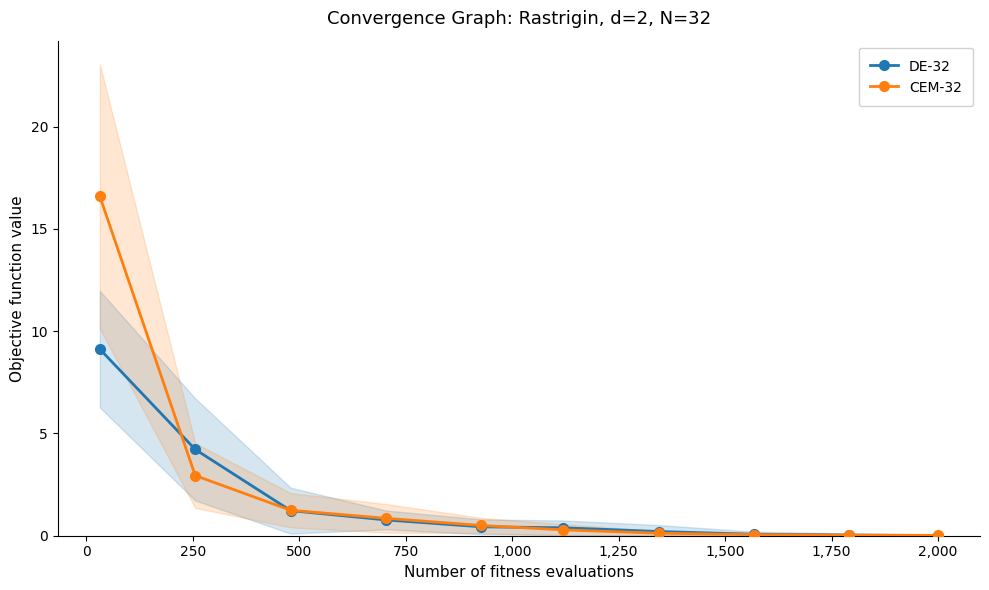

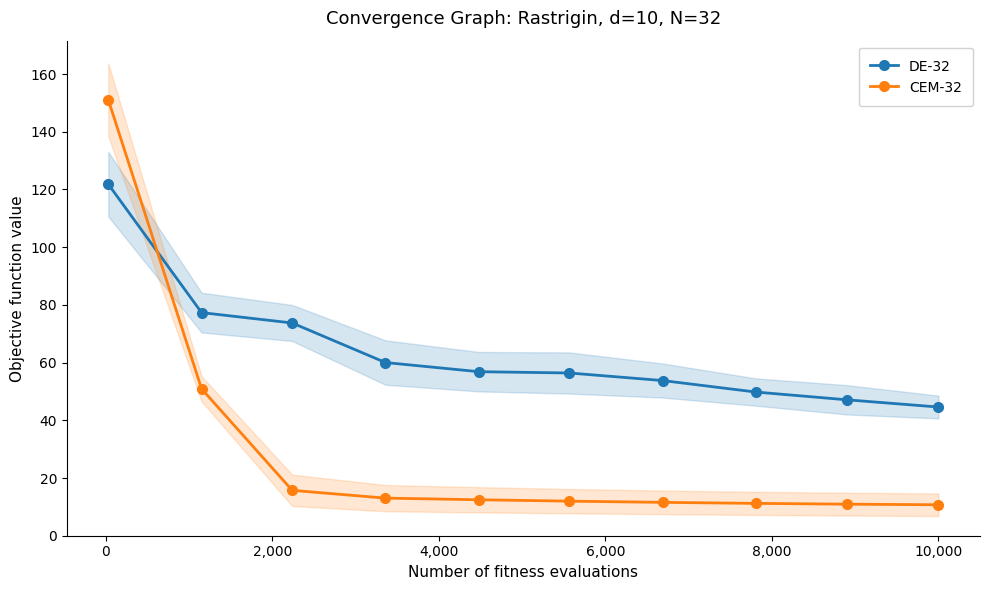

Saved 10 convergence plots to Convergence_Graphs


In [80]:
import matplotlib.ticker as ticker
import numpy as np

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

COLOR_DE = "#1f77b4"
COLOR_CEM = "#ff7f0e"

def plot_convergence(func_name, d, N, save_path=None, show=True):
    d_hists = convergence_data[func_name][d][N]["DE_hists"]
    c_hists = convergence_data[func_name][d][N]["CEM_hists"]

    def extract_stats(hists):
        evals_arr = np.array([x[0] for x in hists[0]])
        vals_arr = np.array([[x[1] for x in run] for run in hists])
        return evals_arr, np.mean(vals_arr, axis=0), np.std(vals_arr, axis=0)

    de_evals, de_mean, de_std = extract_stats(d_hists)
    cem_evals, cem_mean, cem_std = extract_stats(c_hists)
    idx = np.round(np.linspace(0, len(de_evals) - 1, 10)).astype(int)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(de_evals[idx], de_mean[idx], color=COLOR_DE, marker="o", markersize=7, linestyle="-", linewidth=2.0, label=f"DE-{N}", zorder=4)
    ax.fill_between(de_evals[idx], np.maximum(0, de_mean[idx] - de_std[idx]), de_mean[idx] + de_std[idx], color=COLOR_DE, alpha=0.18, zorder=2)
    ax.plot(cem_evals[idx], cem_mean[idx], color=COLOR_CEM, marker="o", markersize=7, linestyle="-", linewidth=2.0, label=f"CEM-{N}", zorder=4)
    ax.fill_between(cem_evals[idx], np.maximum(0, cem_mean[idx] - cem_std[idx]), cem_mean[idx] + cem_std[idx], color=COLOR_CEM, alpha=0.18, zorder=2)
    ax.set_title(f"Convergence Graph: {func_name}, d={d}, N={N}", fontsize=13, fontweight="normal", pad=12)
    ax.set_xlabel("Number of fitness evaluations", fontsize=11)
    ax.set_ylabel("Objective function value", fontsize=11)
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(fontsize=10, framealpha=0.9, edgecolor="#cccccc", borderpad=0.8, handlelength=2.0, handleheight=1.2)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=250, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

plot_convergence("Rastrigin", d=2, N=32)
plot_convergence("Rastrigin", d=10, N=32)

saved_convergence_paths = []
for func_name in FUNCTIONS.keys():
    for d in [2, 10]:
        out = GRAPH_DIR / f"Convergence_{func_name}_d{d}_N32.png"
        plot_convergence(func_name, d=d, N=32, save_path=out, show=False)
        saved_convergence_paths.append(str(out))

print(f"Saved {len(saved_convergence_paths)} convergence plots to {GRAPH_DIR}")

## 8. Tạo Ảnh động (GIF Animations) trực quan hóa không gian $d=2$

Để có cái nhìn sâu sắc nhất về bản chất và hành vi di chuyển của quần thể:
- Hàm `make_gif_animation_fixed` trích xuất `pop_history` của 1 lượt chạy (với seed = MSSV).
- Đường đồng mức (Contour) của bề mặt hàm mục tiêu được vẽ ra làm phông nền (Màu xanh đậm tương ứng vùng giá trị nhỏ).
- Điểm đánh dấu X màu đỏ thể hiện vị trí Cực tiểu toàn cục (Global Optimum) thực sự.
- Các chấm màu cam hiển thị quần thể đang phân bố và hội tụ qua từng thế hệ (Generation).
Ảnh GIF được kết xuất và tự động lưu vào thư mục `GIF_Results`.

Generating GIF files for all benchmark functions...


IndexError: list index out of range

Error in callback <function _draw_all_if_interactive at 0x0000027EAF0CADA0> (for post_execute), with arguments args (),kwargs {}:


ValueError: too many values to unpack (expected 2, got 3)

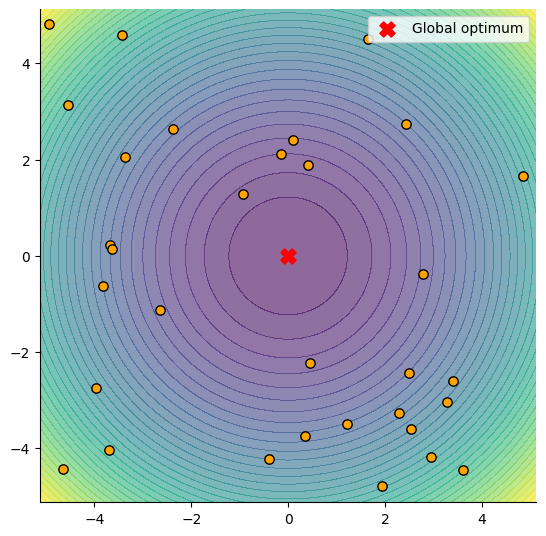

In [81]:
os.makedirs("GIF_Results", exist_ok=True)

def make_gif_animation_fixed(algo_name, func_name):
    d = 2
    N = 32
    max_evals = 2000
    seed = MSSV
    info = FUNCTIONS[func_name]
    func = info["func"]
    bounds = np.array([info["bound"]] * d)

    if algo_name == "DE":
        _, best_hists, pop_hists = differential_evolution(func, bounds, N, max_evals, seed, return_history=True, return_pop_history=True)
    else:
        _, best_hists, pop_hists = cross_entropy_method(func, bounds, N, max_evals, seed, return_history=True, return_pop_history=True)

    fig, ax = plt.subplots(figsize=(6.4, 6.4))
    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)

    for i in range(100):
        for j in range(100):
            Z[i, j] = func(np.array([X[i, j], Y[i, j]]))

    ax.contourf(X, Y, Z, levels=45, cmap="viridis", alpha=0.6)
    opt_x, opt_y = (1.0, 1.0) if func_name == "Rosenbrock" else (0.0, 0.0)
    ax.scatter(opt_x, opt_y, marker="X", color="red", s=120, label="Global optimum")
    scat = ax.scatter([], [], color="orange", edgecolor="black", s=45)
    info_box = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top", fontsize=10, bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8})
    ax.legend(loc="upper right")

    def update(frame):
        pop = pop_hists[frame]
        scat.set_offsets(pop)
        evals, best = best_hists[frame]
        info_box.set_text(f"Gen: {frame + 1}\\nEvals: {evals}\\nBest: {best:.4e}")
        ax.set_title(f"{algo_name} on {func_name}")
        return scat, info_box

    anim = animation.FuncAnimation(fig, update, frames=len(pop_hists), interval=150, blit=False)
    filename = f"GIF_Results/{algo_name}_{func_name}_d2_N32.gif"
    anim.save(filename, writer="pillow", fps=7)
    plt.close()
    return filename

print("Generating GIF files for all benchmark functions...")
gif_manifest = []
for func_name in FUNCTIONS.keys():
    de_gif = make_gif_animation_fixed("DE", func_name)
    cem_gif = make_gif_animation_fixed("CEM", func_name)
    gif_manifest.append({"function": func_name, "DE": de_gif, "CEM": cem_gif})

print(f"Done. Generated {len(gif_manifest) * 2} GIF files in GIF_Results/")

## 9. Bảng So sánh Trực quan Animation

Đoạn mã sau sử dụng HTML để nhúng và chạy trực tiếp các ảnh GIF vừa tạo ra ngay trên Jupyter Notebook. Bảng phân bố làm 2 cột DE và CEM, cho phép bạn dễ dàng so sánh xem quần thể của DE (tính đột biến đa dạng) hay CEM (tính co cụm Gaussian) tiến về phía dấu **X đỏ** hiệu quả hơn ở kích thước quần thể $N=32$.

In [ ]:
if "gif_manifest" not in globals() or len(gif_manifest) == 0:
    display(Markdown("No GIF manifest found. Please run the GIF generation cell first."))
else:
    rows = []
    for item in gif_manifest:
        rows.append(
            f"""
            <tr>
                <td style='padding:8px; font-weight:bold;'>{item['function']}</td>
                <td style='padding:8px;'><img src='{item['DE']}' alt='DE {item['function']}' width='280'></td>
                <td style='padding:8px;'><img src='{item['CEM']}' alt='CEM {item['function']}' width='280'></td>
            </tr>
            """
        )

    html = f"""
    <table style='border-collapse: collapse; width: 100%;'>
        <thead>
            <tr>
                <th style='text-align:left; padding:8px;'>Function</th>
                <th style='text-align:left; padding:8px;'>DE</th>
                <th style='text-align:left; padding:8px;'>CEM</th>
            </tr>
        </thead>
        <tbody>
            {''.join(rows)}
        </tbody>
    </table>
    """
    display(HTML(html))

Function,DE,CEM
Sphere,,
Rastrigin,,
Rosenbrock,,
Ackley,,
Griewank,,
